In [2]:
import os
import sys
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.metrics import (
    roc_curve, auc, classification_report, 
    confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
)
from sklearn.model_selection import train_test_split

# Global visualization styling
sns.set_theme(style="whitegrid", font="sans-serif")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10

# Load engineered feature set & serialized XGBoost model
data_path = "../data/features_engineered.csv"
model_path = "../models/xgb_churn_model.joblib"

assert os.path.exists(data_path), "Engineered feature dataset missing. Run `python src/etl.py`."
assert os.path.exists(model_path), "Trained model missing. Run `python src/train.py`."

df = pd.read_csv(data_path)
model_payload = joblib.load(model_path)
model = model_payload["model"]
feature_names = model_payload["feature_names"]

print(f"Successfully ingested {len(df)} records across {df.shape[1]} raw attributes.")
print(f"Loaded model trained on {len(feature_names)} engineered features.")

Successfully ingested 300 records across 17 raw attributes.
Loaded model trained on 18 engineered features.


C:\Users\Garvit\AppData\Local\Temp\ipykernel_24712\3174942865.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contract_churn, x="Contract_Type", y="True_Churn_Label", palette="Blues_r", ax=axes[0])
C:\Users\Garvit\AppData\Local\Temp\ipykernel_24712\3174942865.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ind_churn, x="True_Churn_Label", y="Industry", palette="viridis", ax=axes[1])
C:\Users\Garvit\AppData\Local\Temp\ipykernel_24712\3174942865.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="True_Churn_Labe

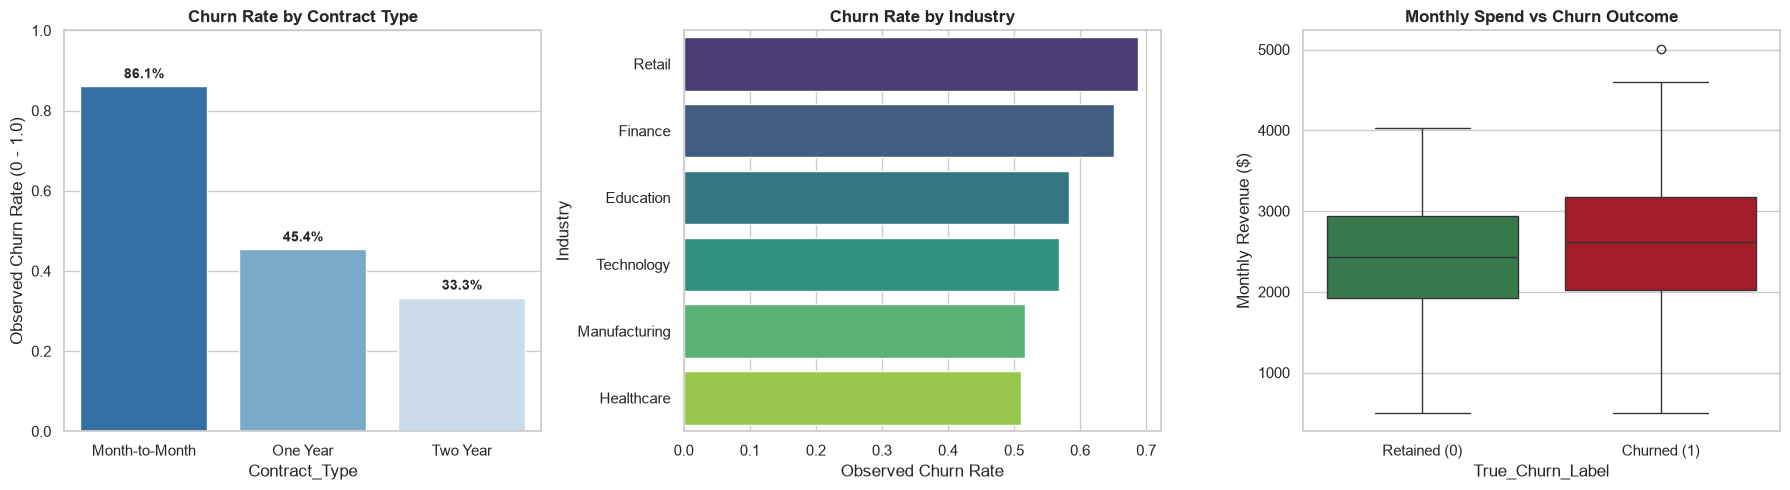

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Churn rate by Contract Structure
contract_churn = df.groupby("Contract_Type")["True_Churn_Label"].mean().reset_index()
sns.barplot(data=contract_churn, x="Contract_Type", y="True_Churn_Label", palette="Blues_r", ax=axes[0])
axes[0].set_title("Churn Rate by Contract Type", fontweight="bold")
axes[0].set_ylabel("Observed Churn Rate (0 - 1.0)")
axes[0].set_ylim(0, 1.0)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1%}", (p.get_x() + p.get_width() / 2., p.get_height() + 0.02), ha='center', fontweight='bold')

# 2. Industry Churn Distribution
ind_churn = df.groupby("Industry")["True_Churn_Label"].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=ind_churn, x="True_Churn_Label", y="Industry", palette="viridis", ax=axes[1])
axes[1].set_title("Churn Rate by Industry", fontweight="bold")
axes[1].set_xlabel("Observed Churn Rate")

# 3. Monthly Spend vs Tenure Boxplot
sns.boxplot(data=df, x="True_Churn_Label", y="Monthly_Charges", palette=["#2E844A", "#BA0517"], ax=axes[2])
axes[2].set_title("Monthly Spend vs Churn Outcome", fontweight="bold")
axes[2].set_xticklabels(["Retained (0)", "Churned (1)"])
axes[2].set_ylabel("Monthly Revenue ($)")

plt.tight_layout()
plt.show()

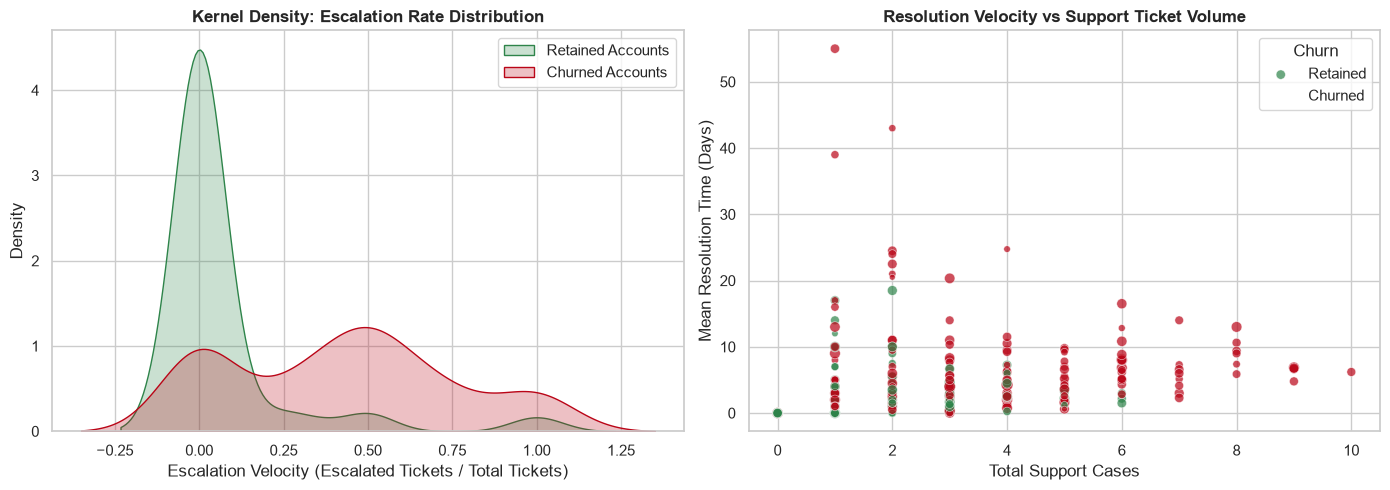

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Escalation Velocity vs Churn
sns.kdeplot(data=df[df["True_Churn_Label"] == 0]["Escalation_Rate"], label="Retained Accounts", fill=True, color="#2E844A", ax=axes[0])
sns.kdeplot(data=df[df["True_Churn_Label"] == 1]["Escalation_Rate"], label="Churned Accounts", fill=True, color="#BA0517", ax=axes[0])
axes[0].set_title("Kernel Density: Escalation Rate Distribution", fontweight="bold")
axes[0].set_xlabel("Escalation Velocity (Escalated Tickets / Total Tickets)")
axes[0].legend()

# 2. Total Cases vs Critical Severity
sns.scatterplot(
    data=df,
    x="Total_Cases",
    y="Avg_Days_To_Resolve",
    hue="True_Churn_Label",
    size="Monthly_Charges",
    palette=["#2E844A", "#BA0517"],
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title("Resolution Velocity vs Support Ticket Volume", fontweight="bold")
axes[1].set_xlabel("Total Support Cases")
axes[1].set_ylabel("Mean Resolution Time (Days)")
axes[1].legend(title="Churn", labels=["Retained", "Churned"])

plt.tight_layout()
plt.show()

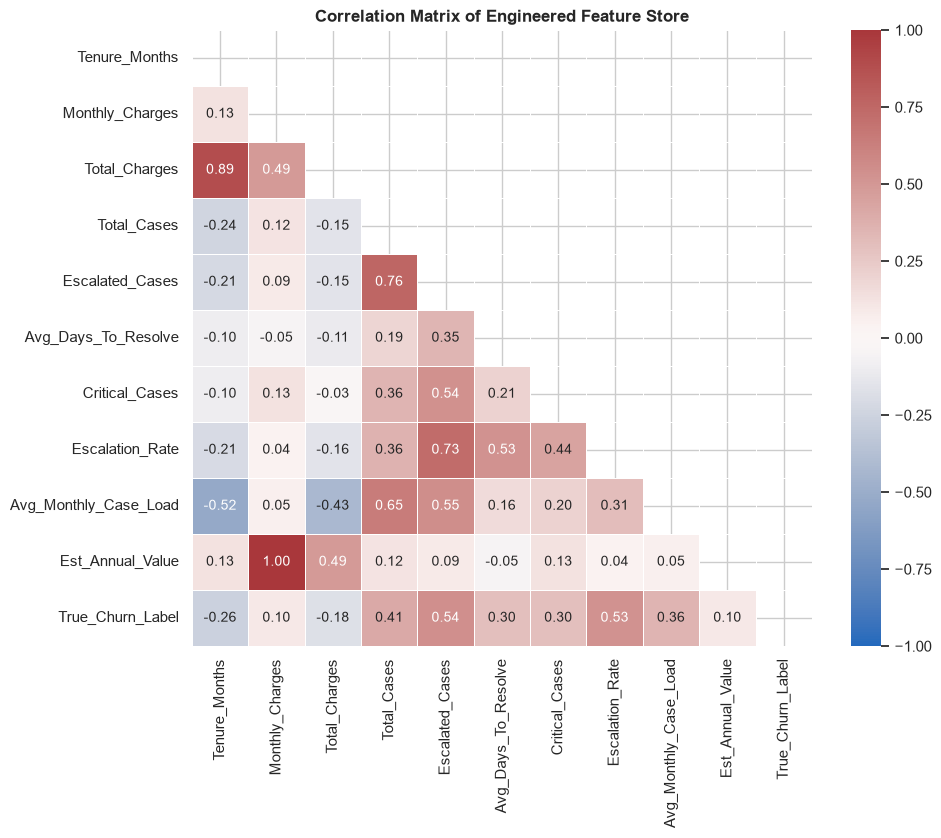

In [5]:
# Numeric feature correlation matrix
numeric_cols = [
    "Tenure_Months", "Monthly_Charges", "Total_Charges", "Total_Cases",
    "Escalated_Cases", "Avg_Days_To_Resolve", "Critical_Cases",
    "Escalation_Rate", "Avg_Monthly_Case_Load", "Est_Annual_Value", "True_Churn_Label"
]

plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Matrix of Engineered Feature Store", fontweight="bold")
plt.show()

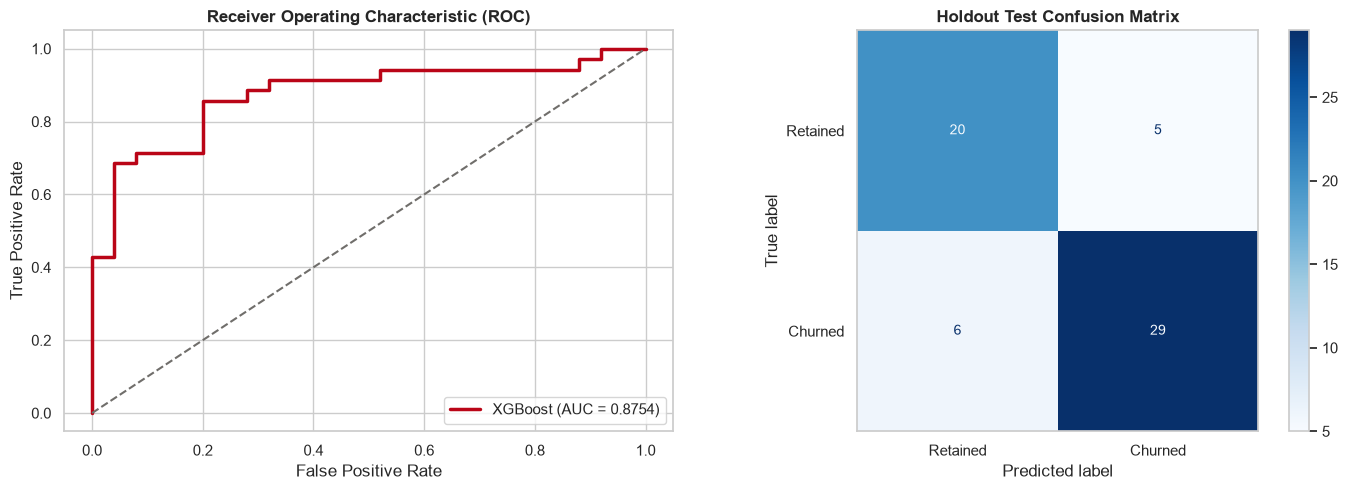


--- Detailed Classification Metrics ---
              precision    recall  f1-score   support

Retained (0)       0.77      0.80      0.78        25
 Churned (1)       0.85      0.83      0.84        35

    accuracy                           0.82        60
   macro avg       0.81      0.81      0.81        60
weighted avg       0.82      0.82      0.82        60



In [6]:
# Prepare encoded feature matrix
X = df.drop(columns=["Account_Ref", "Name", "True_Churn_Label"], errors="ignore")
X_encoded = pd.get_dummies(X, drop_first=True)

# Align feature schema
for col in feature_names:
    if col not in X_encoded.columns:
        X_encoded[col] = 0
X_encoded = X_encoded[feature_names]
y = df["True_Churn_Label"]

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)
y_probs = model.predict_proba(X_test)[:, 1]
y_preds = model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc_val = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color="#BA0517", lw=2.5, label=f"XGBoost (AUC = {roc_auc_val:.4f})")
axes[0].plot([0, 1], [0, 1], color="#706E6B", linestyle="--")
axes[0].set_title("Receiver Operating Characteristic (ROC)", fontweight="bold")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Retained", "Churned"])
disp.plot(ax=axes[1], cmap="Blues", values_format="d")
axes[1].set_title("Holdout Test Confusion Matrix", fontweight="bold")
axes[1].grid(False)

plt.tight_layout()
plt.show()

print("\n--- Detailed Classification Metrics ---")
print(classification_report(y_test, y_preds, target_names=["Retained (0)", "Churned (1)"]))

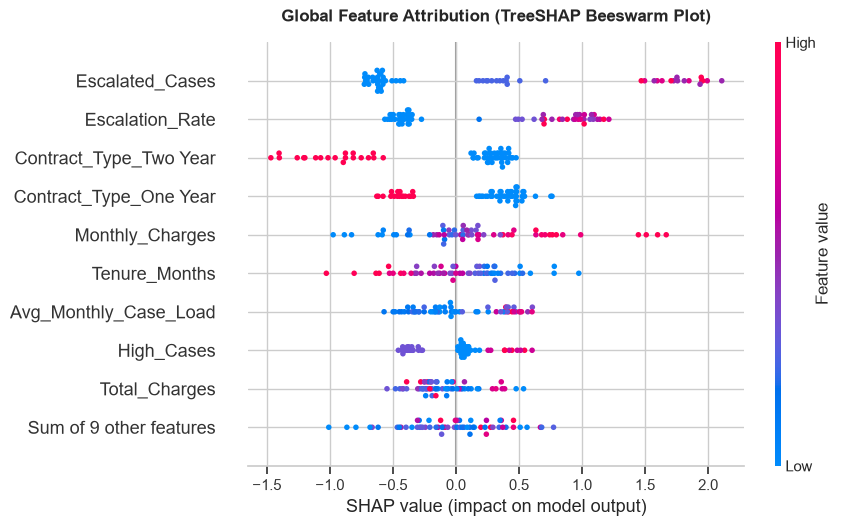

In [7]:
# Compute TreeSHAP values across entire test set
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

plt.figure(figsize=(10, 6))
plt.title("Global Feature Attribution (TreeSHAP Beeswarm Plot)", fontweight="bold", pad=15)
shap.plots.beeswarm(shap_values, max_display=10, show=True)

Inspecting Customer: Cloud Health 23
Model Churn Probability: 99.68%


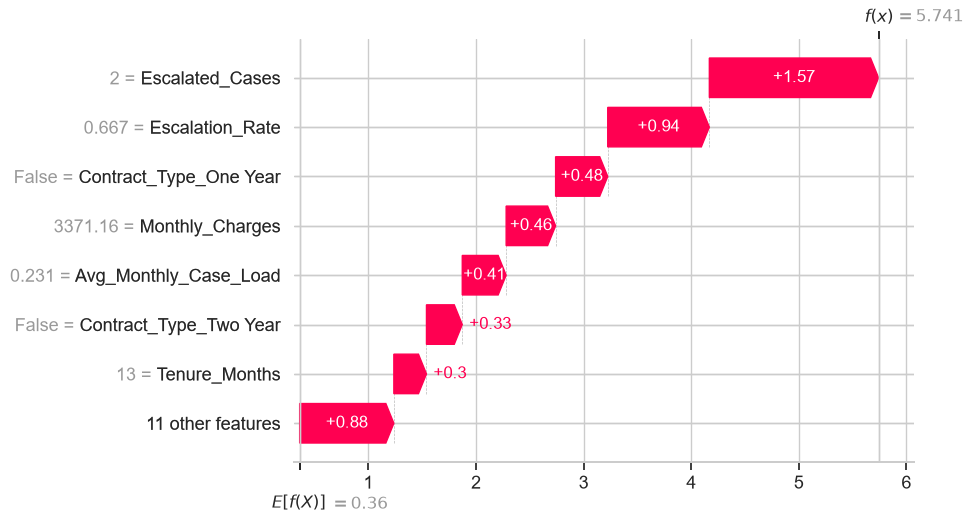

In [8]:
# Inspect single highest-risk customer in the holdout cohort
high_risk_idx = np.argmax(y_probs)
selected_acc_name = df.iloc[X_test.index[high_risk_idx]]["Name"]

print(f"Inspecting Customer: {selected_acc_name}")
print(f"Model Churn Probability: {y_probs[high_risk_idx]:.2%}")

plt.figure(figsize=(9, 5))
shap.plots.waterfall(shap_values[high_risk_idx], max_display=8, show=True)